<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/arvores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import tree

In [2]:

import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

fname = 'drive/MyDrive/Curso Projeto de Bloco: Inteligência Artificial e Machine Learning (GRLCDDR1C1-N2-L2)/dataset_vinhos.csv'

target_col = 'target'
target_col_label='target_label'

cat_cols = ['type']


Mounted at /content/drive


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


wine = pd.read_csv(fname, sep=';')

# Re-defining these variables as their original defining cell was not executed
target_col = 'target'
target_col_label='target_label'
cat_cols = ['type']

# Separate features (X) and target (y)
y = wine[target_col]
X = wine.drop(columns=[target_col, target_col_label])

# Identify numerical features
num_cols = [col for col in X.columns if col not in cat_cols]

# Split data into development and validation sets (80/20 ratio)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Numerical columns identified: {num_cols}")
print(f"Categorical columns identified: {cat_cols}")

Data splitting complete.
X_train shape: (4256, 12)
X_val shape: (1064, 12)
y_train shape: (4256,)
y_val shape: (1064,)
Numerical columns identified: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categorical columns identified: ['type']


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Create a StandardScaler object for numerical features
scaler = StandardScaler()

# Create an OrdinalEncoder object for categorical features
# Corrected: 'handle_unknown' parameter for OrdinalEncoder should be 'use_encoded_value' in newer sklearn versions
# and 'unknown_value' must be specified when 'handle_unknown' is 'use_encoded_value'.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Create a ColumnTransformer named preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', encoder, cat_cols)
    ],
    remainder='passthrough' # Ensure all other columns (if any) are passed through
)

print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")

from sklearn.pipeline import Pipeline

clf = tree.DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    class_weight=None,
)


# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', clf)])


Preprocessing pipeline components (scaler, encoder, preprocessor) created.


In [56]:
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Starting stratified k-fold cross-validation...")

accuracy_scores = []
precision_scores = []
recall_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test_fold)

    # Calculate scores
    accuracy = metrics.accuracy_score(y_test_fold, y_pred)
    precision = metrics.precision_score(y_test_fold, y_pred, average='weighted', zero_division=0)
    recall = metrics.recall_score(y_test_fold, y_pred, average='weighted', zero_division=0)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

    print(f"Fold {fold + 1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

print("Cross-validation complete. Calculating average scores...")

Starting stratified k-fold cross-validation...
Fold 1 - Accuracy: 0.6880, Precision: 0.6873, Recall: 0.6880
Fold 2 - Accuracy: 0.7350, Precision: 0.7300, Recall: 0.7350
Fold 3 - Accuracy: 0.7199, Precision: 0.7171, Recall: 0.7199
Fold 4 - Accuracy: 0.6823, Precision: 0.6710, Recall: 0.6823
Fold 5 - Accuracy: 0.6974, Precision: 0.6886, Recall: 0.6974
Fold 6 - Accuracy: 0.7143, Precision: 0.7078, Recall: 0.7143
Fold 7 - Accuracy: 0.7350, Precision: 0.7307, Recall: 0.7350
Fold 8 - Accuracy: 0.7575, Precision: 0.7546, Recall: 0.7575
Fold 9 - Accuracy: 0.7368, Precision: 0.7312, Recall: 0.7368
Fold 10 - Accuracy: 0.7274, Precision: 0.7266, Recall: 0.7274
Cross-validation complete. Calculating average scores...


In [44]:

# Make predictions
y_pred = model.predict_proba(X_test_fold)[:,1]


(array([80.,  0., 44., 30.,  0.,  8., 30.,  0.,  3.,  3.]),
 array([0.17720916, 0.2527551 , 0.32830104, 0.40384698, 0.47939292,
        0.55493886, 0.6304848 , 0.70603074, 0.78157667, 0.85712261,
        0.93266855]),
 <BarContainer object of 10 artists>)

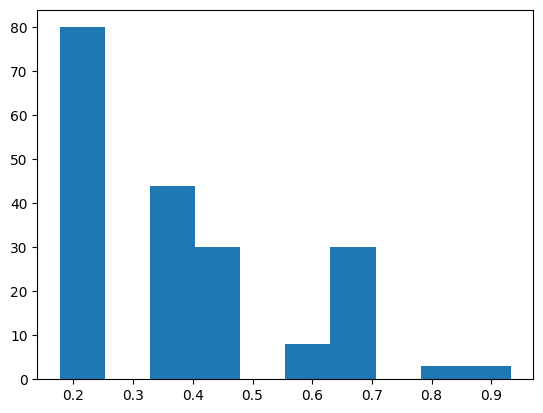

In [45]:
import matplotlib.pyplot as plt

plt.hist(y_pred[y_test_fold==0])

In [46]:
model.steps[1][1].feature_importances_

array([0.        , 0.        , 0.14685158, 0.        , 0.        ,
       0.        , 0.08923675, 0.        , 0.        , 0.        ,
       0.        , 0.76391167])

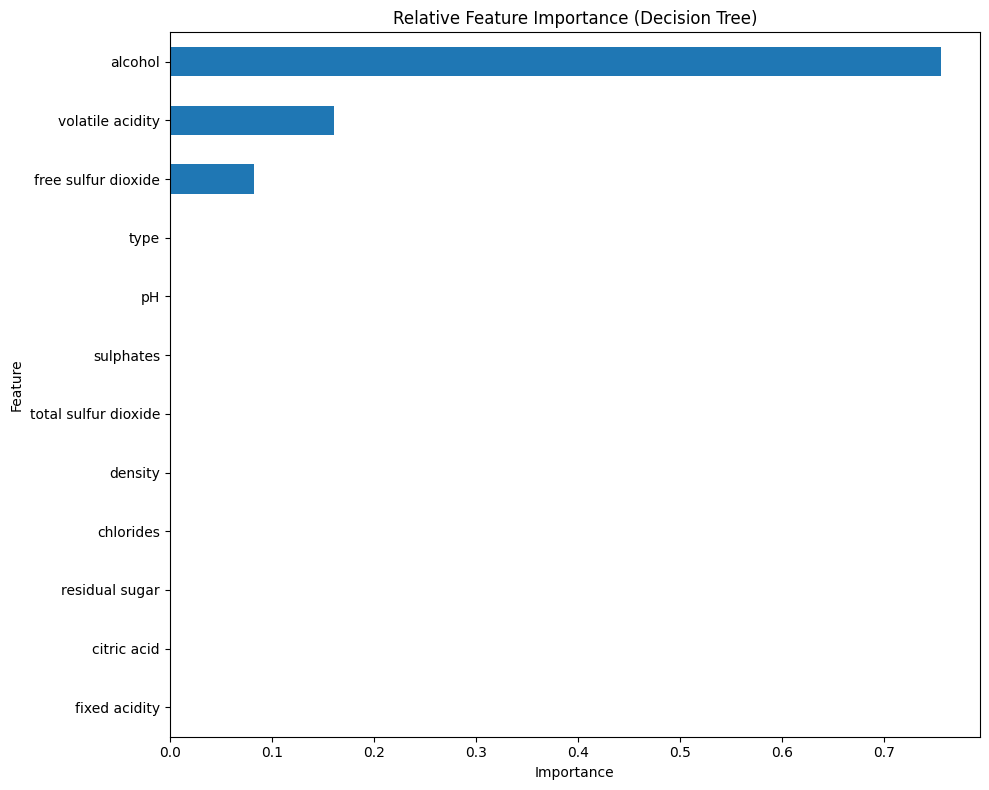

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the trained Decision Tree classifier
feature_importances = model.steps[1][1].feature_importances_

# Get feature names in the correct order
# The preprocessor first processes numerical columns, then categorical columns
feature_names = num_cols + cat_cols

# Create a Pandas Series for easier handling and sorting
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance = feature_importance_series.sort_values(ascending=True)

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))
sorted_importance.plot(kind='barh')
plt.title('Relative Feature Importance (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.feature_selection import RFE

In [49]:
RFE?

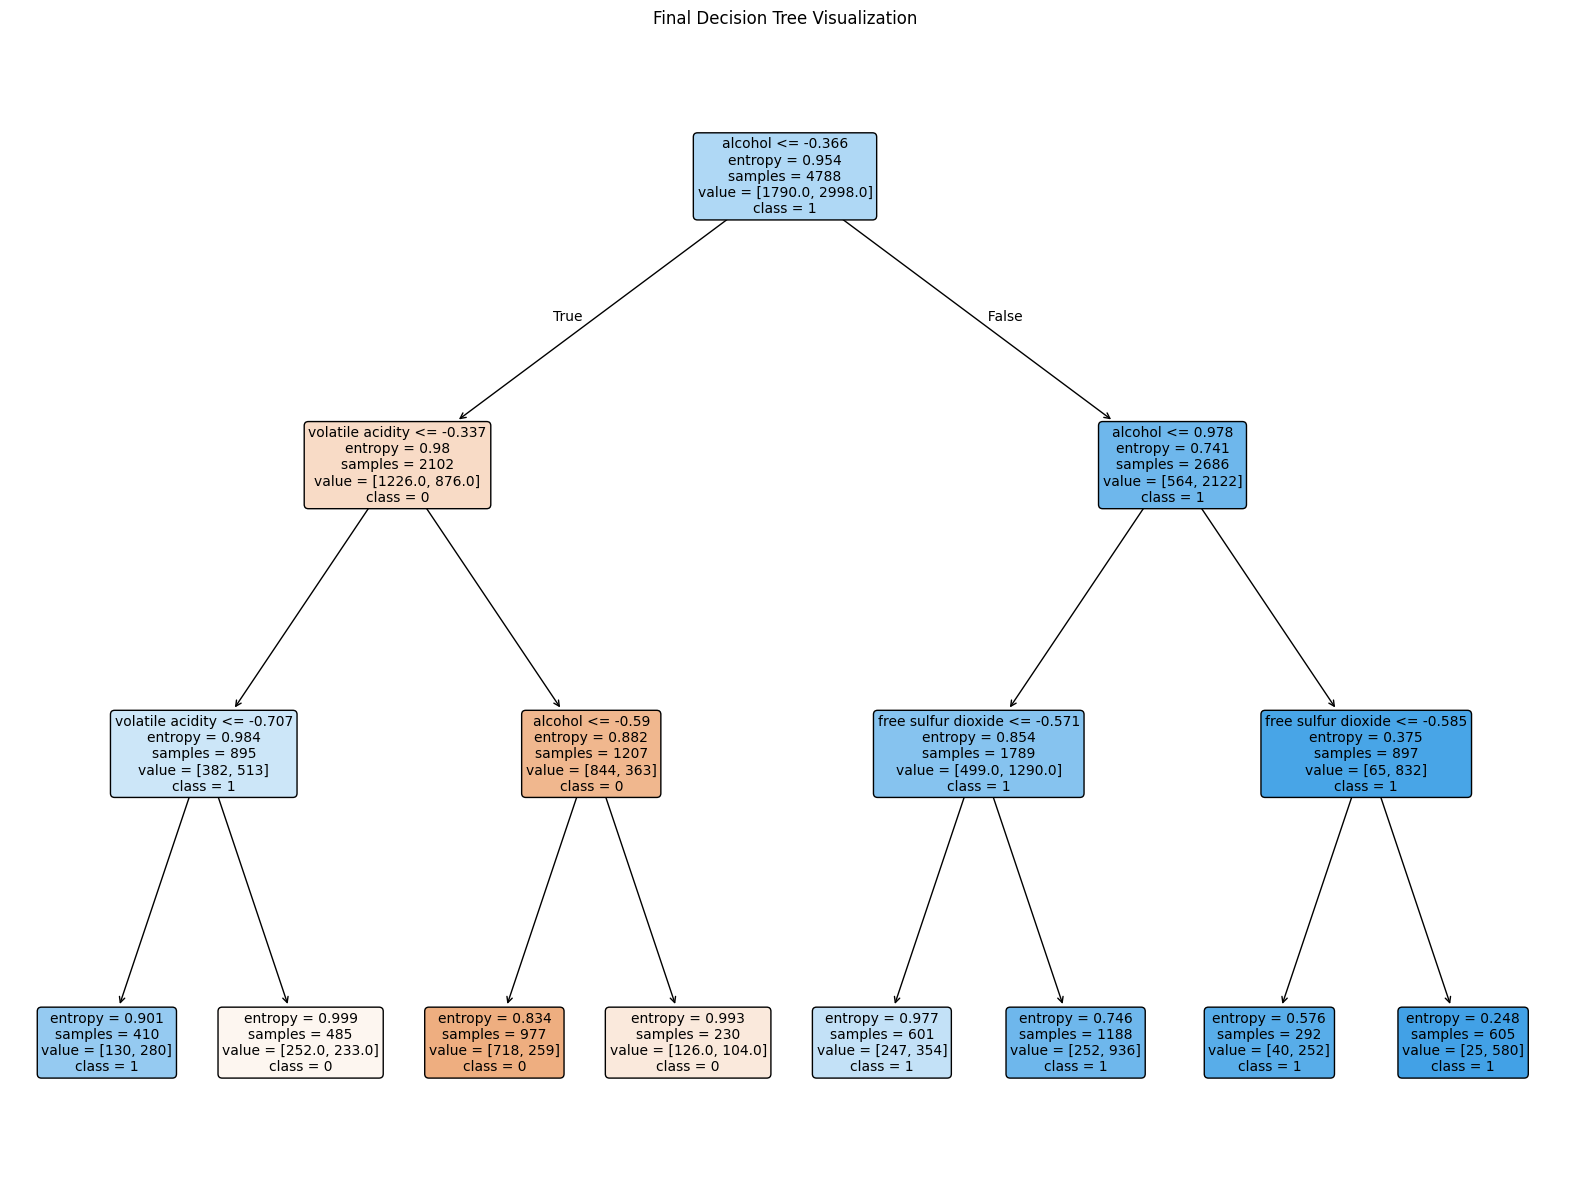

In [59]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the trained DecisionTreeClassifier from the pipeline
decision_tree_classifier = model.named_steps['classifier']

# Get feature names used by the tree (numerical + categorical after encoding)
# The preprocessor applies StandardScaler to num_cols and OrdinalEncoder to cat_cols
# The tree will receive these features in that order.
# For simplicity, we'll use the original feature names. Note that if one-hot encoding was used,
# the feature names would need to reflect the expanded columns.
feature_names_for_tree = num_cols + cat_cols

# Get class names (assuming 0 and 1 are the target classes)
class_names = [str(c) for c in sorted(y.unique())]

plt.figure(figsize=(20, 15))
plot_tree(decision_tree_classifier,
          feature_names=feature_names_for_tree,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Final Decision Tree Visualization')
plt.show()